# Superconductor Tc Extraction — Qwen VLM Pipeline Results

Clean visualisation notebook for the HF-dataset-driven pipeline
(`run_from_hf.py`): materials + synthesis method come from
`structured_synthesis` (no LLM re-extraction), Tc comes from a single
Qwen VLM call per figure (`tc_vlm` column — no `_orig`/`_snip` split,
no separate digitization/linking pass).

Point `RESULTS_DIR` at whichever run you want to inspect:
- `results_superconductors_hf_snippet19` — 19 papers with human/text Tc
  ground truth already in `results/results_superconductors/tc_master_snippet.csv`
  (panel b comparison)
- `results_superconductors_hf_100` — 100-paper trial (panels c/d)

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import sys
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [24]:
FIGSIZE = (4, 4)

# --- switch which run to inspect here ---
RESULTS_DIR_MANUAL_ANNOT = Path(
    "/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/results_superconductors_hf_snippet40"
    # "/home/magled/lematerial-llm-synthesis/data/results_superconductors_hf_snippet19"
)
# judge_score > 4 subset (497 papers) -- re-run with the fixed pipeline
# (Claude digitizer, DeepSeek linker with is_doping_instance, Qwen Tc-read
# with the high-Tc sanity check). Replaces the old hf_100 + hf_random
# combination (one-shot VLM pipeline, before today's linking fix) for
# panels c/d. Ground truth (ground_truth_tc.xlsx) only overlaps 3/17
# papers with this set -- panels c/d use this for the family/synthesis/
# year analysis, NOT for re-validating panel b's accuracy number (that
# still comes from RESULTS_DIR_MANUAL_ANNOT above).
RESULTS_DIRS = [
    Path(
        "/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/results_superconductors_hf_judge4_v2"
    ),
]

# Human-annotated ground truth -- correct source for the panel-b
# comparison. Replaces the old GROUND_TRUTH_CSV
# (results/results_superconductors/tc_master_snippet.csv), which was stale
# and only exact-string-matched materials -> silently capped panel b at n=10.
GROUND_TRUTH_XLSX = Path("/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/ground_truth_tc_40papers.xlsx")
# GROUND_TRUTH_XLSX = Path("ground_truth_tc.xlsx")

In [25]:
SRC_DIR = str(Path().resolve().parents[2] / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
from llm_synthesis.utils.style_utils import set_style, get_palette

set_style("presentation")
sns.set_style("white")

PAL = get_palette()
C_BLUE = PAL[2]
C_ORANGE = PAL[4]
C_PURPLE = PAL[12]
C_PINK = PAL[0]
C_GREY = PAL[8]
C_DGREY = PAL[10]


def set_pub_style(style: str = "manuscript") -> None:
    """Port of icicle.utils.visualization.style.set_style (typography/axes
    only -- color cycle uses this notebook's PAL)."""
    sz = {
        "manuscript": {
            "font": 10,
            "label": 10,
            "title": 10,
            "tick": 9,
            "legend": 9,
            "major_tick": 3,
        },
        "presentation": {
            "font": 12,
            "label": 12,
            "title": 12,
            "tick": 11,
            "legend": 11,
            "major_tick": 4,
        },
    }[style]
    settings = {
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
        "mathtext.sf": "Arial",
        "font.size": sz["font"],
        "axes.labelsize": sz["label"],
        "axes.titlesize": sz["title"],
        "xtick.labelsize": sz["tick"],
        "ytick.labelsize": sz["tick"],
        "legend.fontsize": sz["legend"],
        "legend.title_fontsize": sz["legend"],
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.linewidth": 1.4,
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.grid": False,
        "axes.xmargin": 0.02,
        "axes.ymargin": 0.02,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": sz["major_tick"],
        "ytick.major.size": sz["major_tick"],
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.top": False,
        "ytick.right": False,
        "xtick.color": "black",
        "ytick.color": "black",
        "legend.frameon": False,
        "axes.prop_cycle": plt.cycler("color", PAL),
    }
    for k, v in settings.items():
        mpl.rcParams[k] = v


set_pub_style("manuscript")

## Load

Single CSV, single schema (`tc_vlm`, `synthesis_method` both present --
no merging two separate datasets like the old notebook).

In [26]:
df_manual = pd.read_csv(RESULTS_DIR_MANUAL_ANNOT / "tc_master.csv")

# combine both random-sample runs, drop duplicate (paper_id, material) rows
# (a paper processed in both runs -- keep the first occurrence)
df = pd.concat(
    [pd.read_csv(d / "tc_master.csv") for d in RESULTS_DIRS],
    ignore_index=True,
).drop_duplicates(subset=["paper_id", "material"], keep="first")

print(
    f"manual-annotation set (19 papers): {len(df_manual)} rows, {df_manual['paper_id'].nunique()} papers"
)
print(
    f"random-sample set (combined):      {len(df)} rows, {df['paper_id'].nunique()} papers"
)
print("columns:", list(df.columns))
df.head()

manual-annotation set (19 papers): 98 rows, 40 papers
random-sample set (combined):      731 rows, 497 papers
columns: ['paper_id', 'year', 'material', 'material_normalized', 'is_superconductor', 'tc_text', 'tc_text_onset', 'tc_text_zero', 'tc_vlm', 'tc_vlm_onset', 'tc_vlm_zero', 'tc_vlm_source', 'tc_vlm_source_plot', 'tc_vlm_high_flag', 'tc_best', 'tc_best_source', 'has_text_tc', 'has_vlm_tc', 'synthesis_method', 'synthesis_score']


,paper_id,year,material,material_normalized,is_superconductor,tc_text,tc_text_onset,tc_text_zero,tc_vlm,tc_vlm_onset,tc_vlm_zero,tc_vlm_source,tc_vlm_source_plot,tc_vlm_high_flag,tc_best,tc_best_source,has_text_tc,has_vlm_tc,synthesis_method,synthesis_score
0,2309.14574,2023.0,CsV3Sb5,csv3sb5,False,NaN,NaN,NaN,NaN,NaN,NaN,main plot,FIG. 1,False,NaN,none,False,False,other,NaN
1,1303.3228,2013.0,UCo1-xFexGe,uco1-xfexge,True,NaN,NaN,NaN,5.0,7.5,6.5,inset (fallback),NaN,False,5.0,vlm,False,True,arc melting & induction melting,NaN
2,1210.0397,2012.0,NaFeAs,nafeas,True,NaN,NaN,NaN,20.0,22.0,18.0,bottom-left crop,FIG. 2,False,20.0,vlm,False,True,other,NaN
3,1210.0397,2012.0,FeTe,fete,True,NaN,NaN,NaN,63.5,64.5,62.5,zoomed inset,FIG. 4,False,63.5,vlm,False,True,other,NaN
4,0911.4524,2009.0,Y5Ba6Cu11Oδ,y5ba6cu11odelta,True,NaN,NaN,NaN,92.0,93.0,91.0,bottom-left crop,Figure 1,False,92.0,vlm,False,True,solid-state,NaN


In [27]:
# All known element symbols (case-sensitive canonical form).
_ELEMENTS = {
    "H",
    "He",
    "Li",
    "Be",
    "B",
    "C",
    "N",
    "O",
    "F",
    "Ne",
    "Na",
    "Mg",
    "Al",
    "Si",
    "P",
    "S",
    "Cl",
    "Ar",
    "K",
    "Ca",
    "Sc",
    "Ti",
    "V",
    "Cr",
    "Mn",
    "Fe",
    "Co",
    "Ni",
    "Cu",
    "Zn",
    "Ga",
    "Ge",
    "As",
    "Se",
    "Br",
    "Kr",
    "Rb",
    "Sr",
    "Y",
    "Zr",
    "Nb",
    "Mo",
    "Tc",
    "Ru",
    "Rh",
    "Pd",
    "Ag",
    "Cd",
    "In",
    "Sn",
    "Sb",
    "Te",
    "I",
    "Xe",
    "Cs",
    "Ba",
    "La",
    "Ce",
    "Pr",
    "Nd",
    "Pm",
    "Sm",
    "Eu",
    "Gd",
    "Tb",
    "Dy",
    "Ho",
    "Er",
    "Tm",
    "Yb",
    "Lu",
    "Hf",
    "Ta",
    "W",
    "Re",
    "Os",
    "Ir",
    "Pt",
    "Au",
    "Hg",
    "Tl",
    "Pb",
    "Bi",
    "Po",
    "At",
    "Rn",
    "Ac",
    "Th",
    "Pa",
    "U",
    "Np",
    "Pu",
}
_LOWER_TO_SYMBOL = {e.lower(): e for e in _ELEMENTS}

# f-shell elements that give heavy-fermion physics when paired with a d-metal
_HEAVY_FERMION_ELS = {"Ce", "U", "Yb", "Pu", "Np"}
_TRANSITION_METALS = {
    "Sc",
    "Ti",
    "V",
    "Cr",
    "Mn",
    "Fe",
    "Co",
    "Ni",
    "Cu",
    "Zn",
    "Y",
    "Zr",
    "Nb",
    "Mo",
    "Tc",
    "Ru",
    "Rh",
    "Pd",
    "Ag",
    "Cd",
    "Hf",
    "Ta",
    "W",
    "Re",
    "Os",
    "Ir",
    "Pt",
    "Au",
    "Hg",
}


def _tokenize(s: str) -> list[str] | None:
    """Backtracking tokenizer: split `s` fully into known element symbols.

    Returns None if some suffix can't be tokenized. Tries the 2-letter
    symbol first at each position (real 2-letter elements win over
    accidental 1-letter splits) but backtracks on dead ends -- e.g.
    "yba2cu3o7" must resolve to Y+Ba+Cu+O, not Yb+A(invalid).
    """
    n = len(s)
    memo: dict[int, list[str] | None] = {n: []}

    def solve(i: int) -> list[str] | None:
        if i in memo:
            return memo[i]
        result = None
        for length in (2, 1):
            sym = _LOWER_TO_SYMBOL.get(s[i : i + length])
            if sym is None:
                continue
            rest = solve(i + length)
            if rest is not None:
                result = [sym] + rest
                break
        memo[i] = result
        return result

    return solve(0)


def parse_elements(mat: str) -> set[str]:
    """Extract the set of element symbols present in a formula string.

    Strips everything but letters, tokenizes each letter-run (digits/
    punctuation/doping fractions act as separators) into known element
    symbols via backtracking, falling back to a greedy scan for runs that
    don't fully tokenize. This replaces raw substring search (the old
    classify_family matched "cu"+"ba" anywhere in the string, "re" inside
    any formula containing those two letters, etc.) with actual chemistry,
    at the cost of occasional irreducible ambiguity (e.g. "lafepo" parses
    as La+Fe+Po instead of La+Fe+P+O -- formula strings alone don't encode
    stoichiometry, so this is a real ceiling, not a bug to chase further).
    """
    words = re.findall(r"[a-z]+", str(mat).lower())
    found = set()
    for w in words:
        toks = _tokenize(w)
        if toks is not None:
            found.update(toks)
            continue
        i = 0
        while i < len(w):
            two = _LOWER_TO_SYMBOL.get(w[i : i + 2])
            if two:
                found.add(two)
                i += 2
                continue
            one = _LOWER_TO_SYMBOL.get(w[i])
            if one:
                found.add(one)
            i += 1
    return found


def classify_family(mat: str) -> str:
    els = parse_elements(mat)
    # hydrogen-rich superconducting hydrides (H3S, LaH10-type, under
    # pressure) -- checked first since their record-high Tc (up to ~260K)
    # makes them stand out sharply from every other family; a small
    # element count keeps this from swallowing ordinary hydroxides etc.
    if "H" in els and len(els) <= 3:
        return "Hydrides"
    if "B" in els and ("Mg" in els or "Al" in els):
        return "Borides (MgB$_2$-type)"
    if "Fe" in els and ("As" in els or "P" in els):
        return "Iron pnictides"
    if "Fe" in els and ("Se" in els or "Te" in els):
        return "Iron chalcogenides"
    if "Cu" in els and "O" in els:
        return "Cuprates"
    if "Cu" in els and "Ir" in els and (els & {"S", "Se", "Te"}):
        return "Ir-chalcogenide spinels (CuIr$_2$X$_4$)"
    if "Bi" in els and "O" in els and "S" in els:
        return "Bi-O-S compounds"
    if "Bi" in els and "S" in els:
        return "BiS$_2$-based"
    if "Re" in els and "Mo" in els:
        return "Re-Mo alloys"
    if ("Pd" in els or "Ho" in els) and "Te" in els:
        return "Tellurides"
    if "Ta" in els and "Pd" in els and "S" in els:
        return "Chalcogenides (Ta$_2$PdS$_5$)"
    if els & _HEAVY_FERMION_ELS and els & _TRANSITION_METALS:
        return "Heavy fermions"
    if ("N" in els or "C" in els) and len(els - {"N", "C"}) == 1:
        return "Nitrides/carbides"
    if "V" in els and "Sb" in els:
        return "Kagome metals (AV$_3$Sb$_5$)"
    if "Ni" in els and "O" in els:
        return "Nickelates"
    if "Ni" in els and "As" in els:
        return "Ni-pnictides (non-Fe)"
    if "Cr" in els and "As" in els:
        return "Cr-pnictides"
    if "B" in els:
        return "Other borides"
    if ("Mo" in els and "Sb" in els) or (
        "Nb" in els and ("Sn" in els or "Ge" in els)
    ):
        return "A15-type"
    return "Other"


def is_valid_material(mat: str) -> bool:
    """Reject rows that aren't real materials -- pipeline artifacts, not
    real chemistry: a literal "No materials synthesized" placeholder (the
    extractor correctly found nothing, but the row shouldn't carry a Tc
    or is_superconductor flag), or a leaked series-name fragment like a
    bare doping fraction ("0.05") with no element symbols at all.
    """
    norm = str(mat).lower().replace(" ", "")
    if "nomaterialssynthesized" in norm or norm in (
        "none",
        "unknown",
        "nan",
        "",
    ):
        return False
    return len(parse_elements(mat)) > 0


def prepare(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    valid = d["material_normalized"].apply(is_valid_material)
    n_dropped = (~valid).sum()
    if n_dropped:
        print(
            f"  Dropping {n_dropped} junk material rows (placeholder text / leaked parsing fragments)"
        )
    d = d[valid].copy()
    d["family"] = d["material_normalized"].apply(classify_family)
    for col in ("has_text_tc", "has_vlm_tc"):
        if col in d.columns:
            d[col] = d[col].astype(bool)
    return d


df_manual = prepare(df_manual)
df = prepare(df)

sc_manual = df_manual[df_manual["is_superconductor"] == True].copy()
sc = df[df["is_superconductor"] == True].copy()

year_min = df["year"].min()
year_max = df["year"].max()
print(
    f"manual-annotation set: {len(sc_manual)} / {len(df_manual)} superconductors"
)
print(
    f"random-sample set:     {len(sc)} / {len(df)} superconductors, year range {year_min:.0f}-{year_max:.0f}"
)
print(f"Families (sample): {df['family'].value_counts().to_dict()}")

  Dropping 1 junk material rows (placeholder text / leaked parsing fragments)
  Dropping 45 junk material rows (placeholder text / leaked parsing fragments)
manual-annotation set: 56 / 97 superconductors
random-sample set:     516 / 686 superconductors, year range 2007-2025
Families (sample): {'Other': 225, 'Iron pnictides': 149, 'Cuprates': 101, 'Iron chalcogenides': 51, 'Bi-O-S compounds': 30, 'Ir-chalcogenide spinels (CuIr$_2$X$_4$)': 30, 'Borides (MgB$_2$-type)': 16, 'Heavy fermions': 15, 'Tellurides': 14, 'Nickelates': 11, 'Other borides': 9, 'Nitrides/carbides': 7, 'Hydrides': 6, 'Ni-pnictides (non-Fe)': 6, 'Cr-pnictides': 4, 'BiS$_2$-based': 4, 'Kagome metals (AV$_3$Sb$_5$)': 3, 'Re-Mo alloys': 3, 'A15-type': 2}


In [28]:
# Exclude papers with a manually-inspected implausible high-Tc extraction
# (>=150K, flagged by TcVLMProcessor's high_tc_flag / tc_vlm_high_flag --
# see supp.tex Table "high-tc-failures" for the per-paper writeup). Of
# 7 flagged papers, 6 are VLM misreads (phase-diagram axis confusion or a
# non-superconducting structural/CDW/SDW anomaly misread as Tc); only
# 2209.13299 (H3S, a genuine high-pressure hydride superconductor) is a
# correct extraction, but it's excluded too since ambient-pressure family/
# year plots aren't the right comparison for a 153 GPa result anyway.
HIGH_TC_FAILURE_PAPER_IDS = {
    "1706.01744",
    "1812.09957",
    "2310.03609",
    "2101.03473",
    "2209.13299",
    "1008.2029",
    "1504.00685",
}

n_before = len(sc)
sc = sc[~sc["paper_id"].astype(str).isin(HIGH_TC_FAILURE_PAPER_IDS)].copy()
print(
    f"Excluded {n_before - len(sc)} rows from {len(HIGH_TC_FAILURE_PAPER_IDS)} "
    f"high-Tc-failure papers ({n_before} -> {len(sc)} rows)"
)

Excluded 16 rows from 7 high-Tc-failure papers (516 -> 500 rows)


## Panel b — Tc (Qwen VLM) vs Tc (human/text)

Ground truth is the human-annotated `ground_truth_tc.xlsx` (column
`tc_text_human`), linked to `sc_manual`'s VLM extractions per paper via
`link_tc_ground_truth.py`: string match first (threshold 0.7), then an LLM
name-matcher (`DspyNameMatcherJudge`, same one Fig3/thermocatalysis use) as
a fallback for stoichiometry-notation differences the string matcher can't
resolve (e.g. `Ca1-xLaxFe2As2` vs `Ca0.8La0.2Fe2As2`).

In [37]:
LINKED_TC_CSV = Path("linked_tc_40papers.csv")

if not LINKED_TC_CSV.exists():
    import subprocess

    subprocess.run(
        [
            "python",
            "link_tc_ground_truth.py",
            "--gt",
            str(GROUND_TRUTH_XLSX),
            "--vlm",
            str(RESULTS_DIR_MANUAL_ANNOT / "tc_master.csv"),
            "--output",
            str(LINKED_TC_CSV),
        ],
        check=True,
    )

cmp_df = pd.read_csv(LINKED_TC_CSV).rename(
    columns={"tc_human": "tc_text_human"}
)
print(
    f"Linked {len(cmp_df)} (paper, material) GT rows; "
    f"{cmp_df['vlm_material'].notna().sum()} matched to a VLM row "
    f"({(cmp_df['match_method'] == 'string').sum()} string, "
    f"{(cmp_df['match_method'] == 'llm').sum()} llm)"
)
cmp_df.head(10)

2026/08/01 21:49:22 WARNING dspy.primitives.module: Calling module.forward(...) on DspyNameMatcherJudge directly is discouraged. Please use module(...) instead.
2026/08/01 21:49:26 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.
Traceback (most recent call last):
  File "/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/.venv/lib/python3.11/site-packages/litellm/llms/anthropic/chat/handler.py", line 481, in completion
    response = client.post(
               ^^^^^^^^^^^^
  File "/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/.venv/lib/python3.11/site-packages/litellm/llms/custom_httpx/http_handler.py", line 1085, in post
    _raise_masked_sync_error(e, stream)
  File "/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/.venv/lib/python3.11/site-packages/litellm/llms/custom_httpx/http_handler.py", line 354, in _raise_masked_sync_error
    raise MaskedHTTPStatusError(e, message=_text, text=_text) from None
lit

CalledProcessError: Command '['python', 'link_tc_ground_truth.py', '--gt', '/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/ground_truth_tc_40papers.xlsx', '--vlm', '/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/results_superconductors_hf_snippet40/tc_master.csv', '--output', 'linked_tc_40papers.csv']' returned non-zero exit status 1.

In [40]:
both = cmp_df.dropna(subset=["tc_text_human", "tc_vlm"]).copy()

if len(both) < 3:
    print(
        f"Only {len(both)} matched rows with both tc_text and tc_vlm -- "
        "not enough to plot yet. Re-check RESULTS_DIR / GROUND_TRUTH_CSV, "
        "or wait for the run to finish."
    )
else:
    max_tc = max(both["tc_text_human"].max(), both["tc_vlm"].max()) * 1.1
    fig, ax = plt.subplots(figsize=FIGSIZE)
    sns.regplot(
        x="tc_text_human",
        y="tc_vlm",
        data=both,
        ci=95,
        scatter_kws={
            "s": 45,
            "edgecolors": "k",
            "linewidths": 0.3,
            "zorder": 3,
            "color": C_BLUE,
        },
        line_kws={"lw": 1.5, "color": C_PURPLE},
        ax=ax,
    )
    ax.plot([0, max_tc], [0, max_tc], "k--", lw=1, label="$y = x$")
    r2 = both[["tc_text_human", "tc_vlm"]].corr().iloc[0, 1] ** 2
    mae = (both["tc_text_human"] - both["tc_vlm"]).abs().mean()
    ax.text(
        0.05,
        0.92,
        f"$R^2$ = {r2:.3f}\nMAE = {mae:.1f} K\n$n$ = {len(both)}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=1.0),
    )
    ax.set_xlim(-4, max_tc)
    ax.set_ylim(-4, max_tc)
    ax.set_xlabel("$T_c$ from text (human, K)")
    ax.set_ylabel("$T_c$ from VLM (Qwen, K)")
    ax.set_title("Qwen VLM vs Human Text $T_c$")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_aspect("equal")
    plt.tight_layout()
    # plt.show()
    print(f"R²={r2:.3f}  MAE={mae:.2f} K  n={len(both)}")
    plt.savefig("tc_text_vs_vlm.pdf", bbox_inches="tight")

NameError: name 'cmp_df' is not defined

## Panel b (appendix) — ground-truth strategy comparison

Three ways to define the human ground-truth Tc, re-sliced from the same
linked VLM extractions -- linking (which VLM material corresponds to which
annotated row) only depends on material names, not which Tc column we
read, so no re-linking is needed to compare the three:

- **text** — `tc_text_human` only (Tc as stated in the article text).
- **plot** — `tc_human_from_plot` only (Tc read off the figure by a human
  annotator).
- **text_then_plot** — text value where stated, else fall back to the
  plot-read value.

`text` has the fewest matched pairs (many rows have no stated text Tc) but
the lowest noise (a stated value is more precise than a human's visual
estimate off a plot). `text_then_plot` recovers the same coverage as
`plot` alone while keeping the more precise text value wherever available.

Note: arXiv:1106.4208 (5 rows, a Ca(Fe,La/Ce/Pr)$_2$As$_2$ doping series)
is excluded from `ground_truth_tc.xlsx` pending manual re-verification --
its VLM-read Tc values disagree with the stated ~43 K by an amount and
pattern (one value coincides with a *different* composition's stated Tc
in the same figure) inconsistent with every other row, suggesting a
possible curve-identity mixup within a multi-curve panel rather than
ordinary read noise.

In [41]:
import subprocess

GT_STRATEGIES = ["text", "plot", "text_then_plot"]
STRATEGY_LABELS = {
    "text": "Human Text $T_c$",
    "plot": "Human Plot-Read $T_c$",
    "text_then_plot": "Human Text, else Plot $T_c$",
}

strategy_dfs = {}
for strategy in GT_STRATEGIES:
    out_csv = Path(f"linked_tc_40papers_{strategy}.csv")
    subprocess.run(
        [
            "python",
            "link_tc_ground_truth.py",
            "--gt",
            str(GROUND_TRUTH_XLSX),
            "--vlm",
            str(RESULTS_DIR_MANUAL_ANNOT / "tc_master.csv"),
            "--gt-strategy",
            strategy,
            "--output",
            str(out_csv),
        ],
        check=True,
        capture_output=True,
    )
    strategy_dfs[strategy] = pd.read_csv(out_csv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
strategy_stats = {}

for ax, strategy in zip(axes, GT_STRATEGIES):
    df_s = strategy_dfs[strategy]
    both_s = df_s.dropna(subset=["tc_human", "tc_vlm"]).copy()
    max_tc = max(both_s["tc_human"].max(), both_s["tc_vlm"].max()) * 1.1

    sns.regplot(
        x="tc_human",
        y="tc_vlm",
        data=both_s,
        ci=95,
        scatter_kws={
            "s": 40,
            "edgecolors": "k",
            "linewidths": 0.3,
            "zorder": 3,
            "color": C_BLUE,
        },
        line_kws={"lw": 1.5, "color": C_PURPLE},
        ax=ax,
    )
    ax.plot([0, max_tc], [0, max_tc], "k--", lw=1, label="$y = x$")

    r2 = both_s[["tc_human", "tc_vlm"]].corr().iloc[0, 1] ** 2
    mae = (both_s["tc_human"] - both_s["tc_vlm"]).abs().mean()
    strategy_stats[strategy] = {"n": len(both_s), "r2": r2, "mae": mae}

    ax.text(
        0.05,
        0.92,
        f"$R^2$ = {r2:.3f}\nMAE = {mae:.1f} K\n$n$ = {len(both_s)}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=1.0),
    )
    ax.set_xlim(-4, max_tc)
    ax.set_ylim(-4, max_tc)
    ax.set_xlabel(f"$T_c$ from {STRATEGY_LABELS[strategy]} (K)")
    ax.set_ylabel("$T_c$ from VLM (Qwen, K)")
    ax.set_title(STRATEGY_LABELS[strategy], fontsize=10)
    ax.legend(fontsize=8, loc="lower right")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

print(f"{'strategy':<16} {'n':>4} {'R2':>7} {'MAE (K)':>9}")
for strategy, stats in strategy_stats.items():
    print(
        f"{strategy:<16} {stats['n']:>4} {stats['r2']:>7.3f} {stats['mae']:>9.2f}"
    )

CalledProcessError: Command '['python', 'link_tc_ground_truth.py', '--gt', '/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/ground_truth_tc_40papers.xlsx', '--vlm', '/Users/mlf25/Documents/Entalpic/lematerial-llm-synthesis/data/supercond_data/results_superconductors_hf_snippet40/tc_master.csv', '--gt-strategy', 'text', '--output', 'linked_tc_40papers_text.csv']' returned non-zero exit status 1.

## Panel d — Tc vs year (scale-up demonstration)

439 rows with both Tc and year


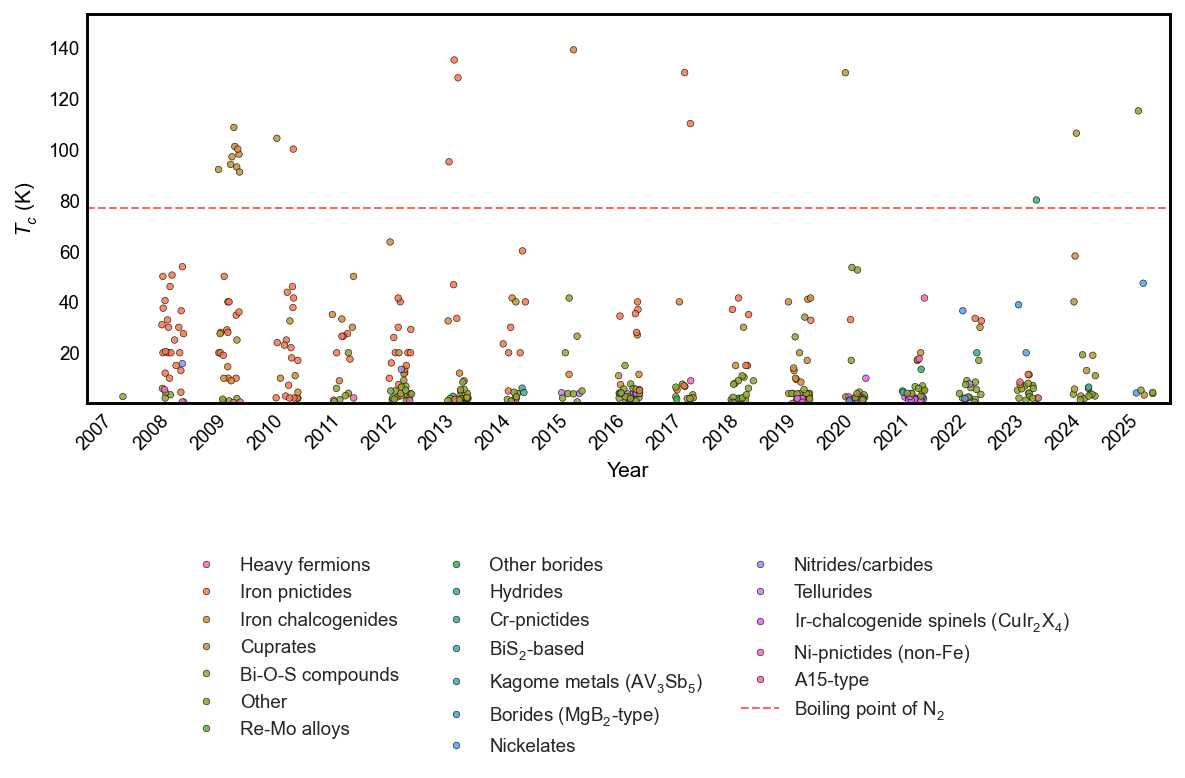

In [42]:
plot_yr = sc.dropna(subset=["tc_best", "year"]).copy()
print(f"{len(plot_yr)} rows with both Tc and year")

if len(plot_yr) < 3:
    print(
        "Not enough rows yet -- re-check RESULTS_DIR or wait for the run to finish."
    )
else:
    rng = np.random.default_rng(0)
    year_jittered = plot_yr["year"] + rng.uniform(-0.2, 0.2, size=len(plot_yr))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=plot_yr,
        x=year_jittered,
        y="tc_best",
        hue="family",
        s=10,
        alpha=0.85,
        edgecolor="k",
        linewidth=0.3,
        ax=ax,
    )
    ax.axhline(
        77,
        color="red",
        linestyle="--",
        lw=1,
        alpha=0.6,
        label="Boiling point of N$_2$",
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("$T_c$ (K)")
    year_min = int(plot_yr["year"].min())
    year_max = int(plot_yr["year"].max())
    ax.set_xlim(year_min - 0.5, year_max + 0.5)
    ax.set_ylim(plot_yr["tc_best"].min(), plot_yr["tc_best"].max() * 1.1)
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f"{int(x)}")
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.35),
        ncol=3,
    )
    plt.tight_layout()
    # plt.show()
    plt.savefig("tc_best_by_family_all.pdf", bbox_inches="tight")

## Panel d (interactive) — hover to see material / paper / trace back to source

In [43]:
import plotly.express as px

plot_yr_px = plot_yr.copy()
plot_yr_px["arxiv_url"] = "https://arxiv.org/abs/" + plot_yr_px[
    "paper_id"
].astype(str)
plot_yr_px["year_jittered"] = year_jittered

fig = px.scatter(
    plot_yr_px,
    x="year_jittered",
    y="tc_best",
    color="family",
    custom_data=["paper_id", "material", "synthesis_method", "arxiv_url"],
)
fig.update_traces(
    marker=dict(size=7, line=dict(width=0.5, color="black")),
    hovertemplate=(
        "<b>%{customdata[1]}</b><br>"
        "Tc = %{y:.1f} K, year %{x:.0f}<br>"
        "synthesis: %{customdata[2]}<br>"
        "arXiv: %{customdata[0]}<br>"
        "<extra></extra>"
    ),
)
fig.add_hline(
    y=77,
    line_dash="dash",
    line_color="red",
    opacity=0.6,
    annotation_text="Boiling point of N$_2$",
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Tc (K)",
    legend_title="Family",
    template="simple_white",
    width=800,
    height=550,
)
fig.show()

500 rows with tc_vlm


(array([278.,  54.,  45.,  45.,  27.,  10.,   2.,   0.,   6.,  13.,  11.,
          3.,   1.,   5.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
        220., 230., 240., 250., 260., 270., 280., 290.]),
 <BarContainer object of 29 artists>)

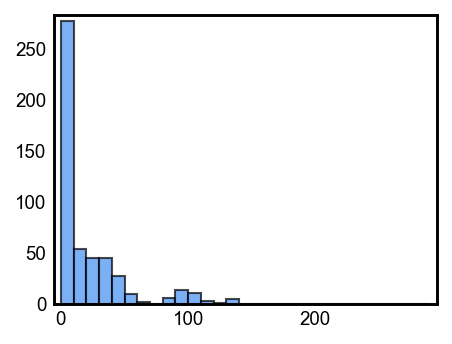

In [44]:
# % of compounds whose Tc is > 150 K
# sc[sc['tc_vlm'] > 100].shape[0] / sc.shape[0]
# histogram of tc_vlm
plot_df = sc.dropna(subset=["tc_vlm"]).copy()
print(f"{len(plot_df)} rows with tc_vlm")

plt.hist(
    plot_df["tc_vlm"],
    bins=np.arange(0, 300, 10),
    color=C_BLUE,
    edgecolor="k",
    alpha=0.7,
)

In [ ]:
# now counts in log scale
plt.hist(
    plot_df["tc_vlm"],
    bins=np.arange(0, 300, 10),
    color=C_BLUE,
    edgecolor="k",
    alpha=0.7,
    log=True,
)

## Panel c — Materials × synthesis method → Tc (judge score > 4)

Single example run, filtered to papers that passed the LLM synthesis-extraction judge (`overall_score > 4`). Static + interactive (hover for material/paper) versions below.


In [69]:
%pip install datasets
from datasets import load_dataset

judge_ds = load_dataset(
    "parquet",
    data_files="hf://datasets/LeMaterial/LeMat-Synth-Papers/superconductor_keywords_and_LLM/full-00000-of-00001.parquet",
    split="train",
)
judge_scores = judge_ds.to_pandas()[["id", "overall_score"]].rename(
    columns={"id": "paper_id", "overall_score": "judge_score"}
)

sc_judge = sc.merge(judge_scores, on="paper_id", how="left")
sc_judge = sc_judge[sc_judge["judge_score"] > 4]
print(f"{len(sc_judge)} rows after filtering (judge_score>4)")
print(sc_judge["family"].value_counts())

Note: you may need to restart the kernel to use updated packages.
439 rows after filtering (judge_score>4)
family
Other                                      162
Iron pnictides                             106
Iron chalcogenides                          38
Cuprates                                    31
Bi-O-S compounds                            25
Ir-chalcogenide spinels (CuIr$_2$X$_4$)     22
Heavy fermions                              11
Tellurides                                  11
Other borides                                5
Nickelates                                   5
Nitrides/carbides                            5
Ni-pnictides (non-Fe)                        5
Cr-pnictides                                 3
Re-Mo alloys                                 2
Hydrides                                     2
BiS$_2$-based                                2
Kagome metals (AV$_3$Sb$_5$)                 2
Borides (MgB$_2$-type)                       1
A15-type                                

439 rows with both Tc and synthesis_method


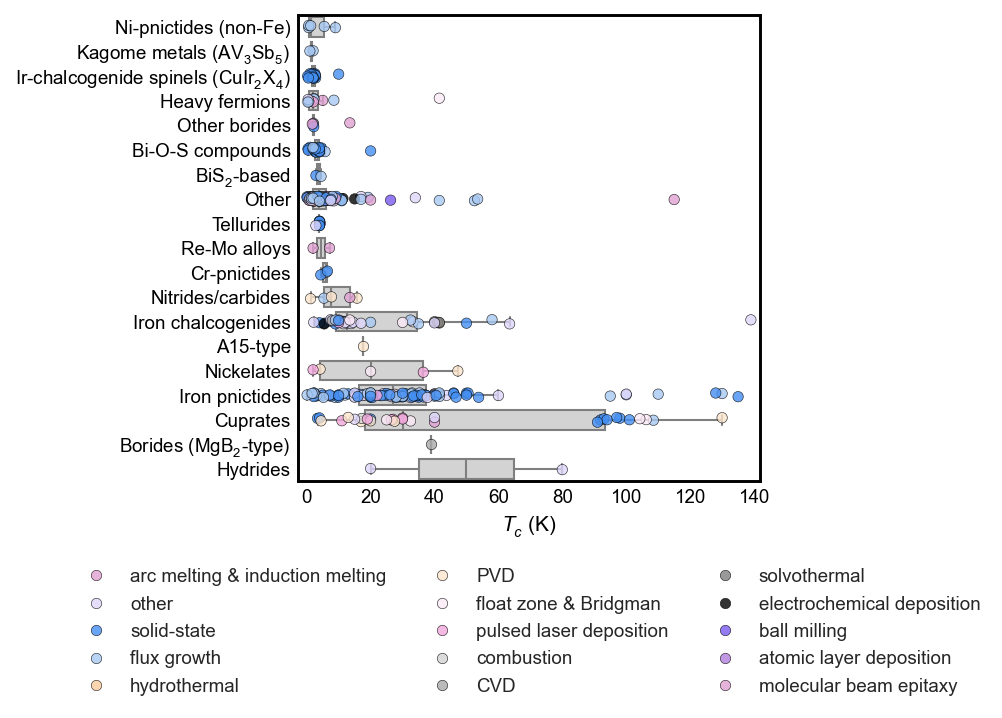

In [70]:
plot_df_judge = sc_judge.dropna(subset=["tc_best", "synthesis_method"]).copy()
plot_df_judge = plot_df_judge[
    plot_df_judge["synthesis_method"].str.strip() != ""
]
print(f"{len(plot_df_judge)} rows with both Tc and synthesis_method")

order = plot_df_judge.groupby("family")["tc_best"].median().sort_values().index
n_methods = plot_df_judge["synthesis_method"].nunique()
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=plot_df_judge,
    x="tc_best",
    y="family",
    order=order,
    color=C_GREY,
    fliersize=0,
    ax=ax,
)
sns.stripplot(
    data=plot_df_judge,
    x="tc_best",
    y="family",
    order=order,
    hue="synthesis_method",
    palette=sns.color_palette(PAL, n_colors=n_methods),
    size=5,
    alpha=0.8,
    edgecolor="k",
    linewidth=0.3,
    ax=ax,
    legend="brief",
)
ax.set_xlabel("$T_c$ (K)")
ax.set_ylabel("")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
)
plt.tight_layout()
plt.show()

### Panel c (interactive) — hover for material / paper


In [71]:
import plotly.express as px

plot_df_judge_px = plot_df_judge.copy()
plot_df_judge_px["arxiv_url"] = "https://arxiv.org/abs/" + plot_df_judge_px[
    "paper_id"
].astype(str)

fig = px.strip(
    plot_df_judge_px,
    x="tc_best",
    y="family",
    color="synthesis_method",
    category_orders={"family": list(order)},
    color_discrete_sequence=PAL,
    custom_data=["material", "paper_id", "synthesis_method", "arxiv_url"],
)
fig.update_traces(
    marker=dict(size=7, line=dict(width=0.5, color="black")),
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "Tc = %{x:.1f} K<br>"
        "synthesis: %{customdata[2]}<br>"
        "arXiv: %{customdata[1]}<br>"
        "<extra></extra>"
    ),
)
fig.update_layout(
    xaxis_title="Tc (K)",
    yaxis_title="",
    legend_title="Synthesis method",
    template="simple_white",
    width=800,
    height=550,
)
fig.show()

## Panel c’ — square boxplots, single categorical dimension each

Same `sc_judge` (judge score > 4) data as above, split into two simpler square
panels instead of one plot with two overlapping categorical dimensions (family × synthesis method):

- by **material family** only (color = family)
- by **synthesis method** only (color = synthesis method)

Each shown for all families/methods and for just the top 6 by count.


In [94]:
import re
import textwrap


def wrap_labels(ax, width=14):
    """Line-break long y-tick category labels."""
    for t in ax.get_yticklabels():
        new_label = textwrap.fill(
            re.sub(r"\s*\([^)]*\)", "", t.get_text()),
            width
        )
        t.set_text(new_label)

    ax.figure.canvas.draw_idle()

### By material family (all families)


/var/folders/br/t_m09nrx5095w0jym2vqnbyr0000gp/T/ipykernel_36123/1797622047.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


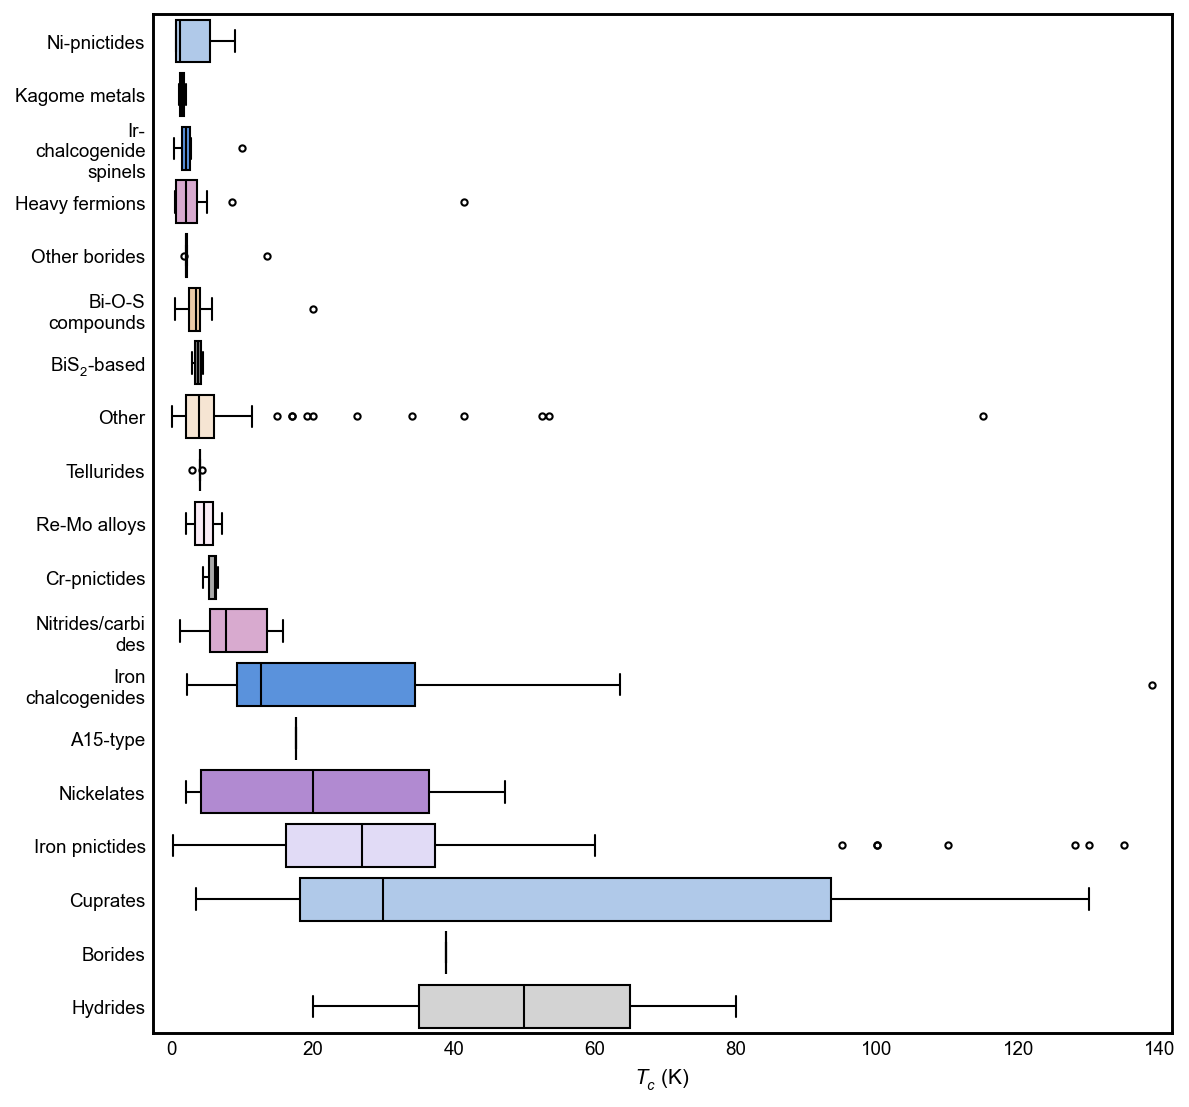

In [73]:
order_family = (
    plot_df_judge.groupby("family")["tc_best"].median().sort_values().index
)
n_family = len(order_family)
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_box_aspect(1)
sns.boxplot(
    data=plot_df_judge,
    x="tc_best",
    y="family",
    order=order_family,
    hue="family",
    palette=sns.color_palette(PAL, n_colors=n_family),
    legend=False,
    fliersize=3,
    ax=ax,
)
ax.set_xlabel("$T_c$ (K)")
ax.set_ylabel("")
# ax.set_title("By family (judge score > 4)", fontsize=10)
wrap_labels(ax)
plt.tight_layout()
# plt.show()
# save plot as pdf
plt.savefig("tc_best_by_family_all.pdf", bbox_inches="tight")

### By material family (top 6 by count)


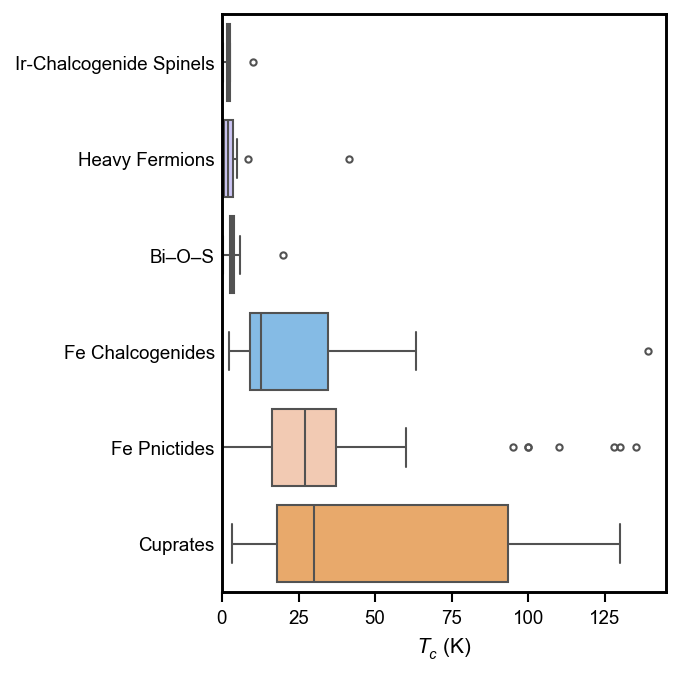

In [166]:
# Reuse the synthesis-method colours
family_colors = {
    "Ir-Chalcogenide Spinels": (0.92, 0.50, 0.80),
    "Heavy Fermions": (0.78, 0.74, 0.99),
    "Bi–O–S": (0.12, 0.50, 0.95),
    "Fe Pnictides": (0.99, 0.78, 0.66),
    "Fe Chalcogenides":  (0.46, 0.74, 0.96),
    "Cuprates": (0.99, 0.66, 0.34),
}

# Remove "Other"
plot_df_judge_no_other = plot_df_judge[
    plot_df_judge["family"] != "Other"
]

top_family = plot_df_judge_no_other["family"].value_counts().nlargest(6).index
plot_df_family_top6 = plot_df_judge_no_other[plot_df_judge_no_other["family"].isin(top_family)]

family_labels = {
    "Heavy fermions": "Heavy Fermions",
    "Iron pnictides": "Fe Pnictides",
    "Iron chalcogenides": "Fe Chalcogenides",
    "Cuprates": "Cuprates",
    "Bi-O-S compounds": "Bi–O–S",
    "Re-Mo alloys": "Re–Mo Alloys",
    "Other borides": "Other Borides",
    "Hydrides": "Hydrides",
    "Cr-pnictides": "Cr Pnictides",
    "BiS$_2$-based": "BiS₂-Based",
    "Kagome metals (AV$_3$Sb$_5$)": "Kagome Metals",
    "Borides (MgB$_2$-type)": "MgB₂-Type Borides",
    "Nickelates": "Nickelates",
    "Nitrides/carbides": "Nitrides & Carbides",
    "Tellurides": "Tellurides",
    "Ir-chalcogenide spinels (CuIr$_2$X$_4$)": "Ir-Chalcogenide Spinels",
    "Ni-pnictides (non-Fe)": "Ni Pnictides",
    "A15-type": "A15-Type"
}

# Copy for plotting only
plot_df_family_top6_plot = plot_df_family_top6.copy()

# Replace labels
plot_df_family_top6["family"] = (
    plot_df_family_top6["family"].replace(family_labels)
)


order_family = (
    plot_df_family_top6.groupby("family")["tc_best"]
    .median()
    .sort_values()
    .index
)
n_family = len(order_family)
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_box_aspect(1.3)
sns.boxplot(
    data=plot_df_family_top6,
    x="tc_best",
    y="family",
    order=order_family,
    hue="family",
    palette=family_colors,
    legend=False,
    fliersize=3,
    ax=ax,
)
ax.set_xlabel("$T_c$ (K)")
ax.set_ylabel("")
# ax.set_title("By family, top 6 (judge score > 4)", fontsize=10)
wrap_labels(ax)

ax.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=5,
    width=1,
)
ax.set_xlim(0, 145)
ax.xaxis.set_ticks_position("bottom")
ax.tick_params(axis="x", bottom=True, direction="out")
ax.minorticks_off()
#plt.tight_layout()
#plt.show()
# save plot as pdf
plt.savefig("tc_best_by_family_top6.pdf", bbox_inches="tight")
plt.savefig("tc_best_by_family_top6.svg", bbox_inches="tight")

### By synthesis method (all methods)


/var/folders/br/t_m09nrx5095w0jym2vqnbyr0000gp/T/ipykernel_36123/1797622047.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


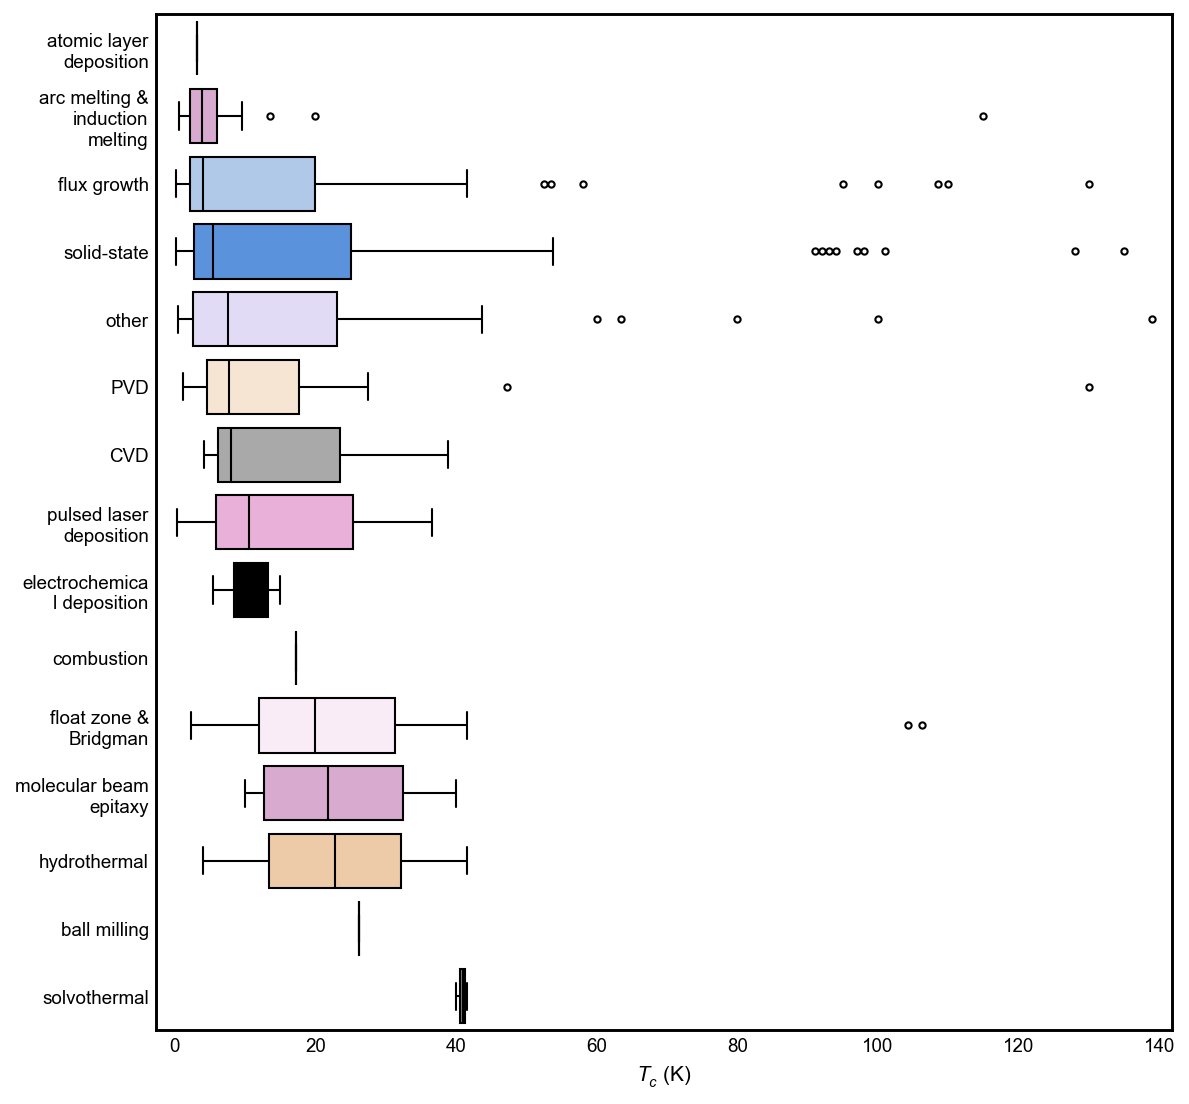

In [ ]:
order_method = (
    plot_df_judge.groupby("synthesis_method")["tc_best"]
    .median()
    .sort_values()
    .index
)
n_method = len(order_method)
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_box_aspect(1)
sns.boxplot(
    data=plot_df_judge,
    x="tc_best",
    y="synthesis_method",
    order=order_method,
    hue="synthesis_method",
    palette=sns.color_palette(PAL, n_colors=n_method),
    legend=False,
    fliersize=3,
    ax=ax,
)
ax.set_xlabel("$T_c$ (K)")
ax.set_ylabel("")
# ax.set_title("By synthesis method (judge score > 4)", fontsize=10)
wrap_labels(ax)
plt.tight_layout()
# plt.show()
# save plot as pdf
plt.savefig("tc_best_by_synthesis_method_all.pdf", bbox_inches="tight")

### By synthesis method (top 6 by count)


In [126]:
import colorsys
import matplotlib.colors as mcolors


def saturate(color, amount=0.3):
    """
    Increase saturation while preserving hue and lightness.

    Parameters
    ----------
    color : matplotlib color
    amount : float
        Fraction of remaining saturation to add (0-1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    # Increase saturation without exceeding 1
    s = s + amount * (1 - s)

    return colorsys.hls_to_rgb(h, l, s)

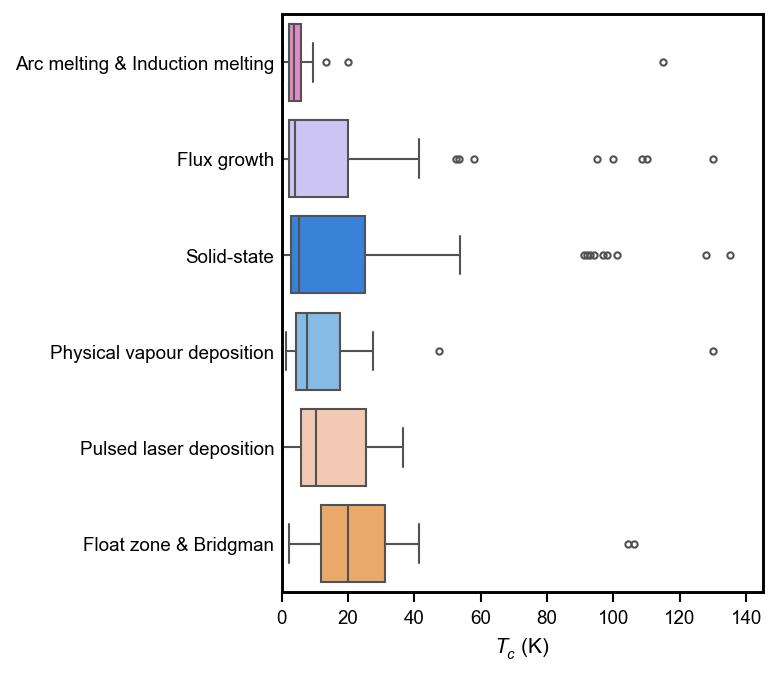

In [165]:
# Remove "Other"
plot_df_judge_no_other = plot_df_judge[
    plot_df_judge["synthesis_method"] != "other"
]

top_method = plot_df_judge_no_other["synthesis_method"].value_counts().nlargest(6).index
plot_df_method_top6 = plot_df_judge_no_other[
    plot_df_judge_no_other["synthesis_method"].isin(top_method)
]

# Define display names
method_labels = {
    "arc melting & induction melting": "Arc melting & Induction melting",
    "flux growth": "Flux growth",
    "solid-state": "Solid-state",
    "PVD": "Physical vapour deposition",
    "float zone & Bridgman": "Float zone & Bridgman",
    "pulsed laser deposition": "Pulsed laser deposition",


}

# Copy for plotting only
plot_df_method_top6_plot = plot_df_method_top6.copy()

# Replace labels
plot_df_method_top6_plot["synthesis_method"] = (
    plot_df_method_top6_plot["synthesis_method"].replace(method_labels)
)

order_method = (
    plot_df_method_top6_plot.groupby("synthesis_method")["tc_best"]
    .median()
    .sort_values()
    .index
)
n_method = len(order_method)

method_palette = {
    "Arc melting & Induction melting": (0.92, 0.50, 0.80),
    "Flux growth": (0.12, 0.50, 0.95),
    "Solid-state": (0.78, 0.74, 0.99),
    "Physical vapour deposition": (0.46, 0.74, 0.96),
    "Pulsed laser deposition": (0.99, 0.66, 0.34),
    "Float zone & Bridgman": (0.99, 0.78, 0.66),
}

palette = [method_palette[m] for m in order_method]

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_box_aspect(1.2)
sns.boxplot(
    data=plot_df_method_top6_plot,
    x="tc_best",
    y="synthesis_method",
    order=order_method,
    hue="synthesis_method",
    palette=palette,
    legend=False,
    fliersize=3,
    ax=ax,
)
ax.set_xlabel("$T_c$ (K)")
ax.set_ylabel("")
# ax.set_title("By synthesis method, top 6 (judge score > 4)", fontsize=10)
wrap_labels(ax)

ax.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=5,
    width=1,
)
ax.set_xlim(0, 145)
ax.xaxis.set_ticks_position("bottom")
ax.tick_params(axis="x", bottom=True, direction="out")
ax.minorticks_off()
#plt.tight_layout()
# plt.show()
# save plot as pdf
plt.savefig("tc_best_by_synthesis_method_top6.pdf", bbox_inches="tight")
plt.savefig("tc_best_by_synthesis_method_top6.svg", bbox_inches="tight")